# Dataload

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Mount Google Drive & load dataset
# ══════════════════════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy import stats

df = pd.read_csv('/content/drive/MyDrive/Microsoft900cases/master_dataset_900.csv')
print(f"Loaded successfully | shape: {df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded successfully | shape: (900, 33)


# 4.1 Descriptive Overview: Industry Composition and Embedding Depth Distribution


In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# BASELINE (Section 4.1) — Setup
# Descriptive baseline of the corpus: industry composition and the overall
# distribution of AI Embedding Depth. Reads the LLM-coded master dataset.
# ══════════════════════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

DATA_PATH = '/content/drive/MyDrive/Microsoft900cases/master_dataset_900.csv'
OUT_DIR   = '/content/drive/MyDrive/Microsoft900cases/'

df = pd.read_csv(DATA_PATH)
N = len(df)

# Shared palette (consistent with Sections 4.2–4.4)
COLORS = {'L1': '#CBD5E1', 'L2': '#60A5FA', 'L3': '#1E3A5F', 'accent': '#F59E0B'}
C_BAR  = '#1E3A5F'   # primary bar colour for count charts
C_GRAY = '#CBD5E1'
LEVEL_LABELS = {1: 'L1 — Surface', 2: 'L2 — Middleware', 3: 'L3 — Native Infrastructure'}
LEVEL_COLORS = [COLORS['L1'], COLORS['L2'], COLORS['L3']]

plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': False})

print(f'Loaded master dataset: {df.shape}')
print(df['arch_level'].value_counts().sort_index())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded master dataset: (900, 33)
arch_level
1    204
2    117
3    579
Name: count, dtype: int64


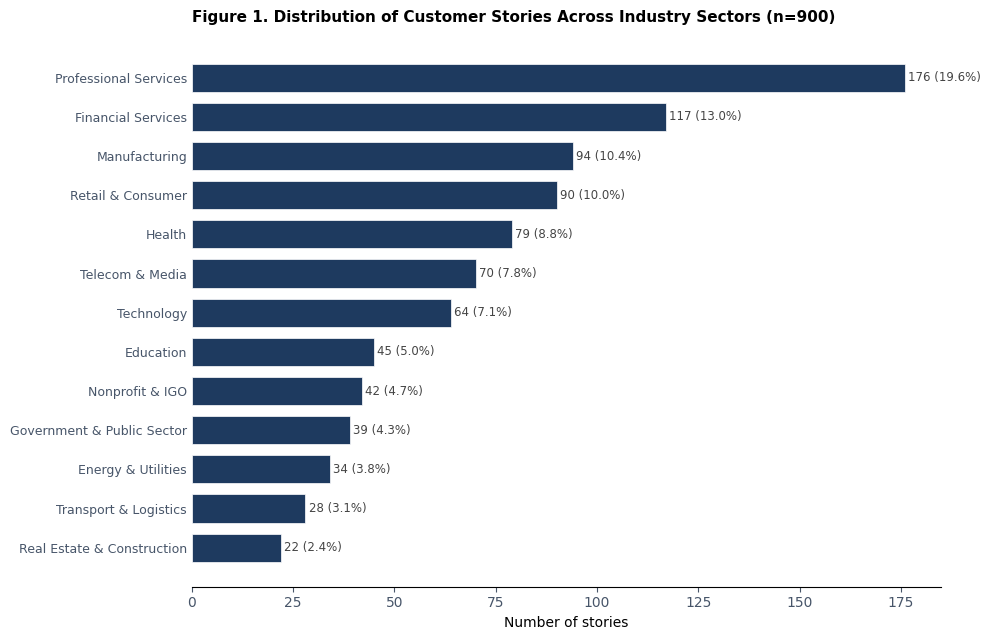

Industry distribution (n=900):
   176 (19.6%)  Professional Services
   117 (13.0%)  Financial Services
    94 (10.4%)  Manufacturing
    90 (10.0%)  Retail & Consumer
    79 ( 8.8%)  Health
    70 ( 7.8%)  Telecom & Media
    64 ( 7.1%)  Technology
    45 ( 5.0%)  Education
    42 ( 4.7%)  Nonprofit & IGO
    39 ( 4.3%)  Government & Public Sector
    34 ( 3.8%)  Energy & Utilities
    28 ( 3.1%)  Transport & Logistics
    22 ( 2.4%)  Real Estate & Construction


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Distribution of Customer Stories Across Industry Sectors (n=900)
# Counts per reclassified sector (industry_reclassified column, already coded).
# ══════════════════════════════════════════════════════════════════════════════

ind_counts = df['industry_reclassified'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6.5))
bars = ax.barh(ind_counts.index.tolist(), ind_counts.values.tolist(),
               color=C_BAR, edgecolor='white', linewidth=0.5, height=0.72)

for bar, val in zip(bars, ind_counts.values):
    ax.text(val + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val} ({val / N * 100:.1f}%)',
            va='center', fontsize=8.5, color='#444')

ax.invert_yaxis()
ax.set_xlabel('Number of stories', fontsize=10)
ax.set_title('Figure 1. Distribution of Customer Stories Across Industry Sectors '
             f'(n={N})', fontsize=11, fontweight='bold', loc='left', pad=12)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0, labelsize=9)
ax.tick_params(colors='#475569')

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig1_industry_composition.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()

print('Industry distribution (n=900):')
for sector, cnt in ind_counts.items():
    print(f'  {cnt:4d} ({cnt / N * 100:4.1f}%)  {sector}')

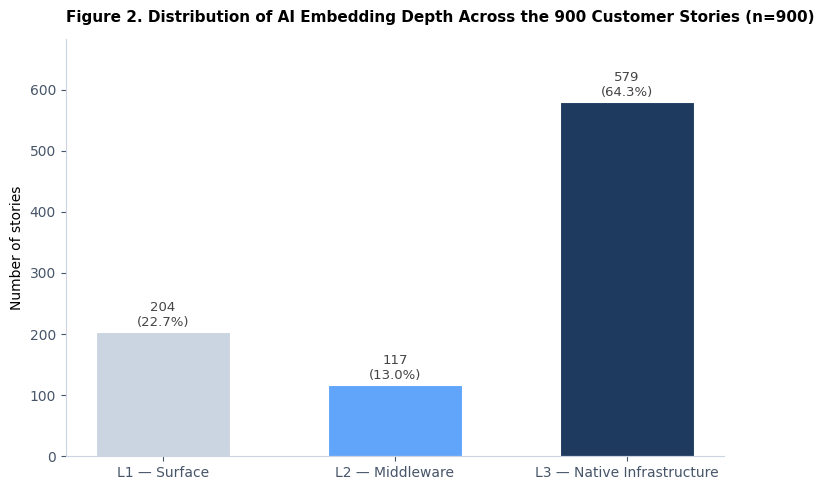

  L1: 204 stories (22.7%)
  L2: 117 stories (13.0%)
  L3: 579 stories (64.3%)


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Distribution of AI Embedding Depth Across the 900 Stories (n=900)
# Final LLM-coded arch_level variable.
# ══════════════════════════════════════════════════════════════════════════════

counts = df['arch_level'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.bar([LEVEL_LABELS[i] for i in counts.index], counts.values,
              color=LEVEL_COLORS, edgecolor='white', linewidth=0.8, width=0.58)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{val}\n({val / N * 100:.1f}%)',
            ha='center', va='bottom', fontsize=9.5, color='#444')

ax.set_ylabel('Number of stories', fontsize=10)
ax.set_ylim(0, max(counts.values) * 1.18)
ax.set_title('Figure 2. Distribution of AI Embedding Depth Across the 900 '
             f'Customer Stories (n={N})', fontsize=11, fontweight='bold',
             loc='left', pad=12)
ax.spines['left'].set_color('#CBD5E1')
ax.spines['bottom'].set_color('#CBD5E1')
ax.tick_params(colors='#475569')

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig2_embedding_depth_distribution.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()

for level in [1, 2, 3]:
    n = (df['arch_level'] == level).sum()
    print(f'  L{level}: {n} stories ({n / N * 100:.1f}%)')

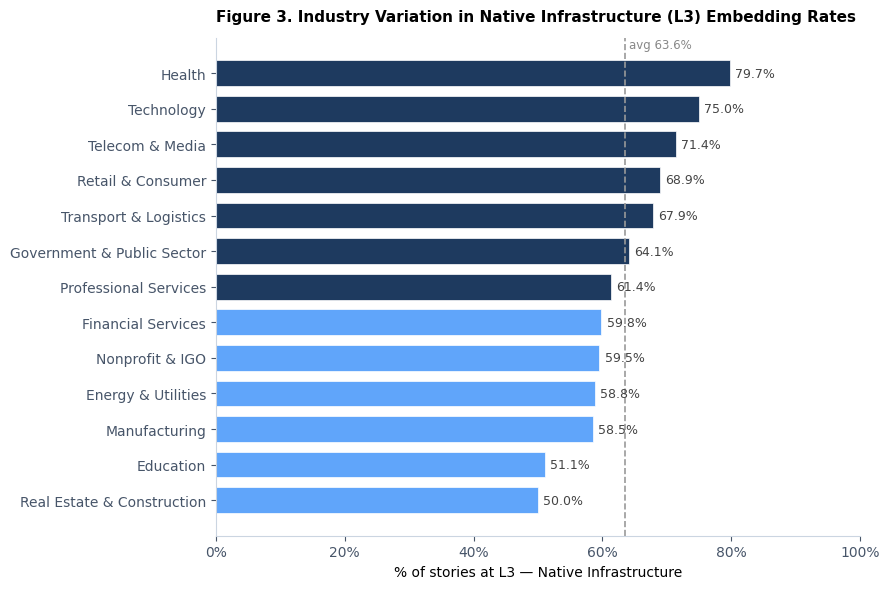

Average L3 rate across industries: 63.6%
  Health                          63/79   = 79.7%
  Technology                      48/64   = 75.0%
  Telecom & Media                 50/70   = 71.4%
  Retail & Consumer               62/90   = 68.9%
  Transport & Logistics           19/28   = 67.9%
  Government & Public Sector      25/39   = 64.1%
  Professional Services          108/176  = 61.4%
  Financial Services              70/117  = 59.8%
  Nonprofit & IGO                 25/42   = 59.5%
  Energy & Utilities              20/34   = 58.8%
  Manufacturing                   55/94   = 58.5%
  Education                       23/45   = 51.1%
  Real Estate & Construction      11/22   = 50.0%


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Industry Variation in Native Infrastructure (L3) Embedding Rates
# % of stories coded L3 within each industry, ranked. Dashed line = mean L3 rate.
# ══════════════════════════════════════════════════════════════════════════════

ct = pd.crosstab(df['industry_reclassified'], df['arch_level'],
                 normalize='index') * 100
l3_pct = ct[3].sort_values(ascending=True) if 3 in ct.columns else pd.Series(dtype=float)

colors_rank = [COLORS['L3'] if v >= 60 else COLORS['L2'] if v >= 40 else COLORS['L1']
               for v in l3_pct.values]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(l3_pct.index, l3_pct.values,
               color=colors_rank, edgecolor='white', linewidth=0.5, height=0.72)

for bar, val in zip(bars, l3_pct.values):
    ax.text(val + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, color='#444')

avg = l3_pct.mean()
ax.axvline(avg, color='#999', linestyle='--', linewidth=1.2)
ax.text(avg + 0.6, len(l3_pct) - 0.3, f'avg {avg:.1f}%',
        fontsize=8.5, color='#888')

ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(PercentFormatter())
ax.set_xlabel('% of stories at L3 — Native Infrastructure', fontsize=10)
ax.set_title('Figure 3. Industry Variation in Native Infrastructure (L3) '
             'Embedding Rates', fontsize=11, fontweight='bold', loc='left', pad=12)
ax.spines[['top', 'right']].set_visible(False)
ax.spines['left'].set_color('#CBD5E1')
ax.spines['bottom'].set_color('#CBD5E1')
ax.tick_params(colors='#475569')

plt.tight_layout()
plt.savefig(OUT_DIR + 'fig3_l3_rate_by_industry.png', dpi=180,
            bbox_inches='tight', facecolor='white')
plt.show()

print(f'Average L3 rate across industries: {avg:.1f}%')
for ind in l3_pct.sort_values(ascending=False).index:
    n_ind = (df['industry_reclassified'] == ind).sum()
    l3_n = ((df['industry_reclassified'] == ind) & (df['arch_level'] == 3)).sum()
    print(f'  {ind:<30s} {l3_n:>3}/{n_ind:<4} = {l3_n / n_ind * 100:.1f}%')

#4.2 Predictive Effect of Triadic Architecture


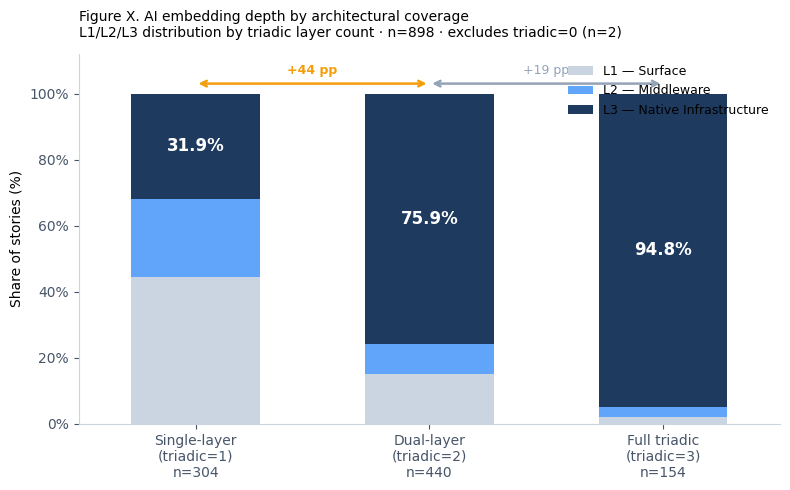

Saved: fig_4_2_1_triadic_embedding.png


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — FIGURE 4
# Stacked bar: L1 / L2 / L3 share by triadic_layers_count
# Analytical move 1 — monotonic gradient
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

df = pd.read_csv('/content/drive/MyDrive/Microsoft900cases/master_dataset_900.csv')

COLORS = {'L1': '#CBD5E1', 'L2': '#60A5FA', 'L3': '#1E3A5F', 'accent': '#F59E0B'}
plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': False})

keep = df[df['triadic_layers_count'].isin([1, 2, 3])].copy()
ct = pd.crosstab(keep['triadic_layers_count'], keep['arch_level'], normalize='index') * 100
ct.columns = ['L1', 'L2', 'L3']
ns = keep['triadic_layers_count'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
x = np.array([1, 2, 3])
labels = [f'Single-layer\n(triadic=1)\nn={ns[1]}',
          f'Dual-layer\n(triadic=2)\nn={ns[2]}',
          f'Full triadic\n(triadic=3)\nn={ns[3]}']

ax.bar(x, ct['L1'], color=COLORS['L1'], label='L1 — Surface', width=0.55)
ax.bar(x, ct['L2'], bottom=ct['L1'], color=COLORS['L2'], label='L2 — Middleware', width=0.55)
ax.bar(x, ct['L3'], bottom=ct['L1'] + ct['L2'], color=COLORS['L3'], label='L3 — Native Infrastructure', width=0.55)

for i, xi in enumerate(x):
    l3_val = ct['L3'].iloc[i]
    bottom = ct['L1'].iloc[i] + ct['L2'].iloc[i]
    ax.text(xi, bottom + l3_val / 2, f"{l3_val:.1f}%",
            ha='center', va='center', color='white', fontsize=12, fontweight='bold')

ax.annotate('', xy=(2, 103), xytext=(1, 103),
            arrowprops=dict(arrowstyle='<->', color=COLORS['accent'], lw=1.8))
ax.text(1.5, 105, '+44 pp', ha='center', va='bottom', color=COLORS['accent'], fontsize=9, fontweight='bold')

ax.annotate('', xy=(3, 103), xytext=(2, 103),
            arrowprops=dict(arrowstyle='<->', color='#94A3B8', lw=1.8))
ax.text(2.5, 105, '+19 pp', ha='center', va='bottom', color='#94A3B8', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_ylabel('Share of stories (%)', fontsize=10)
ax.set_xlim(0.5, 3.5)
ax.set_ylim(0, 112)
ax.set_title('Figure X. AI embedding depth by architectural coverage\n'
             'L1/L2/L3 distribution by triadic layer count · n=898 · excludes triadic=0 (n=2)',
             fontsize=10, loc='left', pad=12)
ax.legend(loc='upper right', frameon=False, fontsize=9)
ax.spines['left'].set_color('#CBD5E1')
ax.spines['bottom'].set_color('#CBD5E1')
ax.tick_params(colors='#475569')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Microsoft900cases/fig_4_2_1_triadic_embedding.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: fig_4_2_1_triadic_embedding.png")

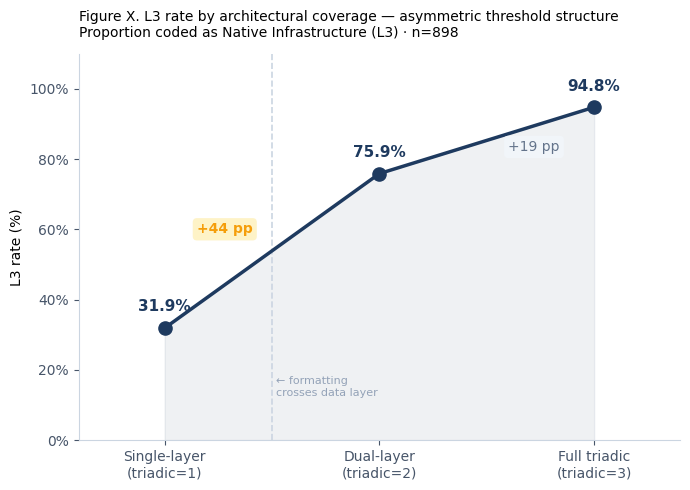

Saved: fig_4_2_2_threshold_asymmetry.png


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — FIGURE 5
# Line chart: L3 rate across triadic levels with asymmetry callout
# Analytical move 2 — threshold asymmetry
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

df = pd.read_csv('/content/drive/MyDrive/Microsoft900cases/master_dataset_900.csv')

COLORS = {'L3': '#1E3A5F', 'accent': '#F59E0B'}
plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': False})

l3_rates = {1: 31.9, 2: 75.9, 3: 94.8}
x_vals = list(l3_rates.keys())
y_vals = list(l3_rates.values())

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(x_vals, y_vals, color=COLORS['L3'], linewidth=2.5, zorder=3)
ax.scatter(x_vals, y_vals, color=COLORS['L3'], s=90, zorder=4)
ax.fill_between(x_vals, y_vals, alpha=0.07, color=COLORS['L3'])

for x, y in zip(x_vals, y_vals):
    ax.annotate(f'{y}%', xy=(x, y), xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=11, fontweight='bold', color=COLORS['L3'])

mid_y = (31.9 + 75.9) / 2
ax.text(1.28, mid_y + 5, '+44 pp', ha='center', color=COLORS['accent'],
        fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='#FEF3C7', ec='none'))

mid_y2 = (75.9 + 94.8) / 2
ax.text(2.72, mid_y2 - 3, '+19 pp', ha='center', color='#64748B',
        fontsize=10, bbox=dict(boxstyle='round,pad=0.3', fc='#F1F5F9', ec='none'))

ax.axvline(1.5, color='#CBD5E1', linestyle='--', lw=1.2, zorder=1)
ax.text(1.52, 12, '← formatting\ncrosses data layer', fontsize=8, color='#94A3B8', va='bottom')

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Single-layer\n(triadic=1)', 'Dual-layer\n(triadic=2)', 'Full triadic\n(triadic=3)'], fontsize=10)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_ylabel('L3 rate (%)', fontsize=10)
ax.set_ylim(0, 110)
ax.set_xlim(0.6, 3.4)
ax.set_title('Figure X. L3 rate by architectural coverage — asymmetric threshold structure\n'
             'Proportion coded as Native Infrastructure (L3) · n=898',
             fontsize=10, loc='left', pad=12)
ax.spines['left'].set_color('#CBD5E1')
ax.spines['bottom'].set_color('#CBD5E1')
ax.tick_params(colors='#475569')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Microsoft900cases/fig_4_2_2_threshold_asymmetry.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: fig_4_2_2_threshold_asymmetry.png")


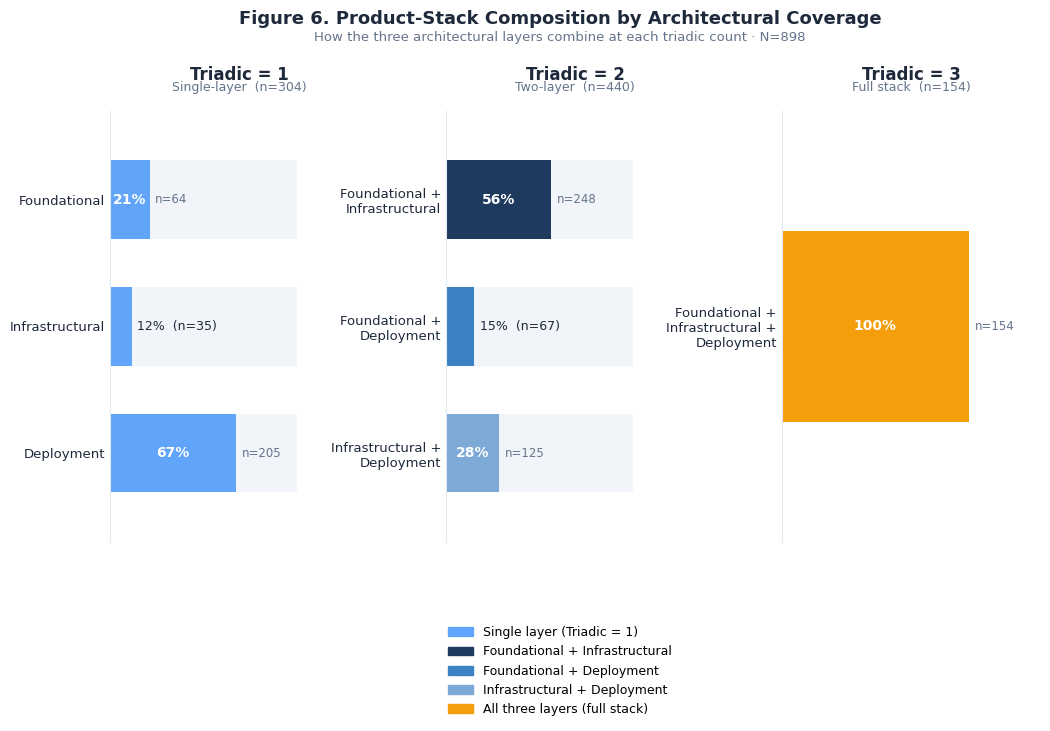

Triadic split — T1=304  T2=440  T3=154  (N=898)
T1: Foundational=64  Infrastructural=35  Deployment=205
T2: F+I=248  F+D=67  I+D=125


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 6 — Product-Stack Composition by Architectural Coverage
# For each triadic_layers_count, which architectural layers make up the stack.
# Panel 1 (single-layer): uniform colour. Panel 2 (two-layer): colour-coded pairs.
# Panel 3 (full stack): accent. Palette consistent with Sections 4.1–4.4.
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── LAYER MAP ─────────────────────────────────────────────────────────────────
LAYER_MAP = {
    'Azure OpenAI Service':1,'Azure OpenAI':1,'Azure AI Foundry':1,
    'Azure AI Services':1,'Azure AI Studio':1,'Azure AI and Machine Learning':1,
    'Azure Machine Learning':1,'Azure Machine Learning studio':1,
    'Azure AI Search':1,'Azure AI Document Intelligence':1,'Azure AI Speech':1,
    'Azure AI Language':1,'Azure AI Vision':1,'Azure AI Bot Service':1,
    'Azure AI Content Safety':1,'Azure AI Translator':1,'Azure AI Foundry Models':1,
    'Azure AI Model Catalog':1,'Azure AI Video Indexer':1,'Azure AI Content Understanding':1,
    'Azure AI Agent Service':1,'Azure AI Foundry Agent Service':1,'Azure AI Service':1,
    'Azure AI Immersive Reader':1,'Azure AI Metrics Advisor':1,
    'Azure AI and Machine Learning (AI)':1,'Azure OpenAI in Foundry Models':1,
    'Azure Document Intelligence in Foundry Tools':1,'Azure Speech in Foundry Tools':1,
    'Foundry Models':1,'Foundry Tools':1,'Microsoft Foundry':1,'Agents':1,
    'Azure Phi':1,'Microsoft Dragon Copilot':1,'Azure Open AI Service':1,
    'Azure Open Datasets':1,'Microsoft Azure Data Manager for Agriculture':1,
    'Azure':2,'Azure App Service':2,'Azure Kubernetes Service':2,'Azure Container Apps':2,
    'Azure Container Registry':2,'Azure Functions':2,'Azure Virtual Machines':2,
    'Azure Blob Storage':2,'Azure SQL Database':2,'Azure SQL':2,
    'Azure Cosmos DB':2,'Azure Databricks':2,'Azure Data Factory':2,
    'Azure Data Lake Storage':2,'Azure Synapse Analytics':2,'Azure Database for PostgreSQL':2,
    'Azure Database for MySQL':2,'Azure Cache for Redis':2,'Azure Files':2,
    'Azure Storage':2,'Azure Monitor':2,'Azure API Management':2,'Azure Logic Apps':2,
    'Azure Service Bus':2,'Azure Event Hubs':2,'Azure DevOps':2,'Azure Key Vault':2,
    'Azure Operator Call Protection':2,'Azure Managed Identity Services':2,
    'Azure IoT Hub':2,'Azure IoT Edge':2,'Azure Communication Services':2,
    'Azure Stream Analytics':2,'Azure Data Explorer':2,'Azure Backup':2,
    'Azure Firewall':2,'Azure VPN Gateway':2,'Azure Bastion':2,'Azure Arc':2,
    'Azure Stack':2,'Azure HPC':2,'Azure Compute':2,'Azure Compute Gallery':2,
    'Azure Virtual Network':2,'Azure Managed Redis':2,'Azure Container Instances':2,
    'GitHub':2,'Visual Studio':2,'Visual Studio Code':2,'SQL Server':2,
    'Microsoft Entra ID':2,'Microsoft Entra':2,'Microsoft Entra External ID':2,
    'Microsoft Entra Verified ID':2,'Microsoft Sentinel':2,'Microsoft Defender':2,
    'Microsoft Defender for Cloud':2,'Microsoft Defender for Endpoint':2,
    'Microsoft Defender XDR':2,'Microsoft Defender for Business':2,
    'Microsoft Defender Threat Intelligence':2,'Microsoft Defender for Cloud Apps':2,
    'Microsoft Defender for Identity':2,'Microsoft Purview':2,
    'Microsoft Purview Information Protection':2,'Intelligent Data Platform':2,
    'OneLake':2,'Microsoft Fabric':2,'Real-Time Analytics':2,
    'Linux on Azure':2,'SAP on Azure':2,'Oracle on Azure':2,'Windows Server':2,'.NET':2,
    'Microsoft 365 Copilot':3,'Microsoft Copilot':3,'Microsoft Copilot Studio':3,
    'Microsoft Copilot for Microsoft 365':3,'Microsoft Copilot for Sales':3,
    'Microsoft Copilot for Service':3,'Microsoft Copilot for Security':3,
    'Microsoft Security Copilot':3,'Microsoft Copilot for Dynamics 365':3,
    'Microsoft 365 Copilot Chat':3,'GitHub Copilot':3,'Microsoft Teams':3,
    'Microsoft 365':3,'Power BI':3,'Power Apps':3,'Power Automate':3,
    'Microsoft Power Platform':3,'SharePoint':3,'OneDrive':3,'Outlook':3,
    'Excel':3,'Word':3,'PowerPoint':3,'Dataverse':3,'Power Pages':3,
    'Dynamics 365':3,'Dynamics 365 Customer Service':3,'Dynamics 365 Sales':3,
    'Dynamics 365 Finance':3,'Dynamics 365 Contact Center':3,
    'Dynamics 365 Customer Insights':3,'Dynamics 365 Supply Chain Management':3,
    'Dynamics 365 Field Service':3,'Dynamics 365 Commerce':3,
    'Dynamics 365 Business Central':3,'Dynamics 365 Human Resources':3,
    'Dynamics 365 Project Operations':3,'Dynamics 365 AI':3,'Dynamics CRM':3,
    'Microsoft Intune':3,'Windows 11':3,'Windows 365':3,
    'Microsoft Viva':3,'Microsoft Viva Insights':3,'Microsoft Viva Engage':3,
    'Microsoft Graph':3,'Microsoft Edge':3,'Microsoft':3,
    'Dynamics 365 Customer Insights - Data':3,'Dynamics 365 Customer Voice':3,
}

# ── COMPUTE ───────────────────────────────────────────────────────────────────
def get_layers(products_str):
    if pd.isna(products_str):
        return frozenset()
    prods = [p.strip() for p in str(products_str).split('\n') if p.strip()]
    return frozenset(LAYER_MAP.get(p) for p in prods if LAYER_MAP.get(p))

df['layer_set'] = df['Products Used'].apply(get_layers)

t1 = df[df['triadic_layers_count'] == 1].copy()
t2 = df[df['triadic_layers_count'] == 2].copy()
t3 = df[df['triadic_layers_count'] == 3].copy()
t1['single_layer'] = t1['layer_set'].apply(lambda s: list(s)[0])
t2['pair']         = t2['layer_set'].apply(lambda s: tuple(sorted(s)))
t1_counts = t1['single_layer'].value_counts()
t2_counts = t2['pair'].value_counts()
t1_total, t2_total, t3_total = len(t1), len(t2), len(t3)
N_all = t1_total + t2_total + t3_total

# ── PALETTE (consistent with 4.1–4.4) ─────────────────────────────────────────
NAVY='#1E3A5F'; MID='#60A5FA'; LIGHT='#CBD5E1'; ACCENT='#F59E0B'
P_FI='#1E3A5F'; P_FD='#3B82C4'; P_ID='#7DA9D6'   # two-layer pair colours
TEXT='#1E293B'; SUB='#64748B'; BORDER='#E2E8F0'

plt.rcParams.update({'font.family':'DejaVu Sans'})
fig, axes = plt.subplots(1, 3, figsize=(12, 5.6), facecolor='white',
                         gridspec_kw={'width_ratios':[1,1,1], 'wspace':0.30})

def hbars(ax, labels, values, colors, total, title, subtitle):
    y = np.arange(len(labels))[::-1]
    for yi, lab, val, col in zip(y, labels, values, colors):
        pct = val/total*100 if total else 0
        ax.barh(yi, total, height=0.62, color='#F1F5F9', zorder=1)
        ax.barh(yi, val,   height=0.62, color=col,       zorder=2)
        if val > total*0.20:
            ax.text(val/2, yi, f'{pct:.0f}%', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white', zorder=3)
            ax.text(val+total*0.03, yi, f'n={val}', ha='left', va='center',
                    fontsize=8.5, color=SUB, zorder=3)
        else:
            ax.text(val+total*0.03, yi, f'{pct:.0f}%  (n={val})', ha='left',
                    va='center', fontsize=9, color=TEXT, zorder=3)
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9.5, color=TEXT)
    ax.set_xlim(0, total*1.38); ax.set_ylim(-0.7, len(labels)-0.3); ax.set_xticks([])
    for sp in ['top','right','bottom']: ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color(BORDER); ax.tick_params(axis='y', length=0)
    ax.set_title(title, fontsize=12, fontweight='bold', color=TEXT, pad=22, loc='center')
    ax.text(0.5, 1.04, subtitle, transform=ax.transAxes, ha='center', va='bottom',
            fontsize=9, color=SUB)

# Panel 1 — single-layer, uniform colour
hbars(axes[0], ['Foundational','Infrastructural','Deployment'],
      [t1_counts.get(1,0), t1_counts.get(2,0), t1_counts.get(3,0)],
      [MID, MID, MID], t1_total, 'Triadic = 1', f'Single-layer  (n={t1_total})')
# Panel 2 — two-layer, colour-coded pairs
hbars(axes[1],
      ['Foundational +\nInfrastructural','Foundational +\nDeployment','Infrastructural +\nDeployment'],
      [t2_counts.get((1,2),0), t2_counts.get((1,3),0), t2_counts.get((2,3),0)],
      [P_FI, P_FD, P_ID], t2_total, 'Triadic = 2', f'Two-layer  (n={t2_total})')
# Panel 3 — full stack, accent
hbars(axes[2], ['Foundational +\nInfrastructural +\nDeployment'],
      [t3_total], [ACCENT], t3_total, 'Triadic = 3', f'Full stack  (n={t3_total})')

fig.suptitle('Figure 6. Product-Stack Composition by Architectural Coverage',
             fontsize=13, fontweight='bold', color=TEXT, x=0.5, y=1.06, ha='center')
fig.text(0.5, 1.005,
         f'How the three architectural layers combine at each triadic count · N={N_all}',
         ha='center', fontsize=9.5, color=SUB)

legend = [mpatches.Patch(color=MID,   label='Single layer (Triadic = 1)'),
          mpatches.Patch(color=P_FI,  label='Foundational + Infrastructural'),
          mpatches.Patch(color=P_FD,  label='Foundational + Deployment'),
          mpatches.Patch(color=P_ID,  label='Infrastructural + Deployment'),
          mpatches.Patch(color=ACCENT,label='All three layers (full stack)')]
fig.legend(handles=legend, loc='upper center', ncol=1, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.02), handletextpad=0.8)

plt.savefig('/content/drive/MyDrive/Microsoft900cases/fig6_product_stack_composition.png',
            dpi=180, bbox_inches='tight', facecolor='white')
plt.show()

print(f'Triadic split — T1={t1_total}  T2={t2_total}  T3={t3_total}  (N={N_all})')
print(f'T1: Foundational={t1_counts.get(1,0)}  Infrastructural={t1_counts.get(2,0)}  Deployment={t1_counts.get(3,0)}')
print(f'T2: F+I={t2_counts.get((1,2),0)}  F+D={t2_counts.get((1,3),0)}  I+D={t2_counts.get((2,3),0)}')

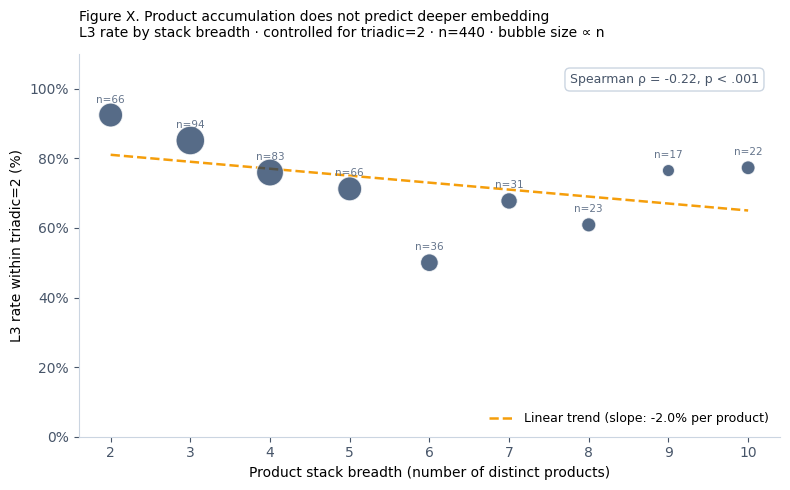

Saved: fig_4_2_3_density_null.png


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — FIGURE 7
# Bubble scatter: product stack breadth vs L3 rate, controlled for triadic=2
# Analytical move 3 — density null result
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy import stats

df = pd.read_csv('/content/drive/MyDrive/Microsoft900cases/master_dataset_900.csv')

COLORS = {'L3': '#1E3A5F', 'accent': '#F59E0B'}
plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': False})

sub2 = df[df['triadic_layers_count'] == 2]
grp = sub2.groupby('product_stack_breadth').agg(
    n=('arch_level', 'count'),
    l3_rate=('arch_level', lambda x: (x == 3).mean() * 100)
).reset_index()
grp = grp[grp['product_stack_breadth'] <= 10]  # exclude stack=11 (n=2, unreliable)

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(grp['product_stack_breadth'], grp['l3_rate'],
           s=grp['n'] * 4.5, color=COLORS['L3'], alpha=0.75, zorder=3,
           edgecolors='white', linewidth=0.8)

z = np.polyfit(grp['product_stack_breadth'], grp['l3_rate'], 1)
p = np.poly1d(z)
x_line = np.linspace(grp['product_stack_breadth'].min(), grp['product_stack_breadth'].max(), 100)
ax.plot(x_line, p(x_line), color=COLORS['accent'], linewidth=1.8, linestyle='--',
        label=f'Linear trend (slope: {z[0]:.1f}% per product)', zorder=2)

for _, row in grp.iterrows():
    ax.annotate(f"n={int(row['n'])}", xy=(row['product_stack_breadth'], row['l3_rate']),
                xytext=(0, 9), textcoords='offset points',
                ha='center', fontsize=7.5, color='#64748B')

rho, _ = stats.spearmanr(sub2['product_stack_breadth'], sub2['arch_level'])
ax.text(0.97, 0.95, f"Spearman ρ = {rho:.2f}, p < .001",
        transform=ax.transAxes, ha='right', va='top', fontsize=9, color='#475569',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#CBD5E1'))

ax.set_xlabel('Product stack breadth (number of distinct products)', fontsize=10)
ax.set_ylabel('L3 rate within triadic=2 (%)', fontsize=10)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_ylim(0, 110)
ax.set_xticks(range(2, 11))
ax.set_title('Figure X. Product accumulation does not predict deeper embedding\n'
             'L3 rate by stack breadth · controlled for triadic=2 · n=440 · bubble size ∝ n',
             fontsize=10, loc='left', pad=12)
ax.legend(frameon=False, fontsize=9, loc='lower right')
ax.spines['left'].set_color('#CBD5E1')
ax.spines['bottom'].set_color('#CBD5E1')
ax.tick_params(colors='#475569')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Microsoft900cases/fig_4_2_3_density_null.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: fig_4_2_3_density_null.png")


#4.3 Industry Variation in Embedding Outcomes: Regramming Under Equivalent Architectural Conditions


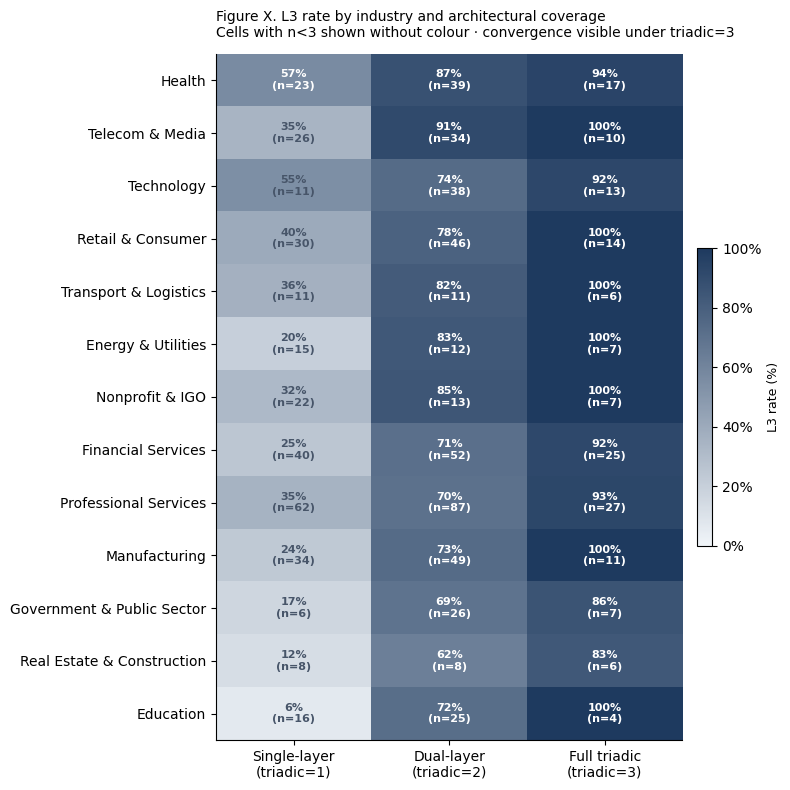

Saved: fig_4_3_1_heatmap.png


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — FIGURE 8
# Heatmap: L3 rate by industry × triadic level
# Analytical move 3 — convergence under triadic=3
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

df = pd.read_csv('/content/drive/MyDrive/Microsoft900cases/master_dataset_900.csv')

plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': False})

# Build matrix: rows=industries, cols=triadic levels 1/2/3
industries_ordered = [
    'Health', 'Telecom & Media', 'Technology', 'Retail & Consumer',
    'Transport & Logistics', 'Energy & Utilities', 'Nonprofit & IGO',
    'Financial Services', 'Professional Services', 'Manufacturing',
    'Government & Public Sector', 'Real Estate & Construction', 'Education'
]

matrix = []
annot = []
for ind in industries_ordered:
    row_vals = []
    row_annot = []
    for t in [1, 2, 3]:
        sub = df[(df['industry_reclassified'] == ind) & (df['triadic_layers_count'] == t)]
        if len(sub) >= 3:
            val = (sub['arch_level'] == 3).mean() * 100
            row_vals.append(val)
            row_annot.append(f'{val:.0f}%\n(n={len(sub)})')
        else:
            row_vals.append(np.nan)
            row_annot.append(f'n<3')
    matrix.append(row_vals)
    annot.append(row_annot)

matrix = np.array(matrix, dtype=float)

fig, ax = plt.subplots(figsize=(8, 8))

cmap = mcolors.LinearSegmentedColormap.from_list('thesis', ['#F1F5F9', '#1E3A5F'])
im = ax.imshow(matrix, cmap=cmap, vmin=0, vmax=100, aspect='auto')

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Single-layer\n(triadic=1)', 'Dual-layer\n(triadic=2)', 'Full triadic\n(triadic=3)'], fontsize=10)
ax.set_yticks(range(len(industries_ordered)))
ax.set_yticklabels(industries_ordered, fontsize=10)

# Annotate cells
for i in range(len(industries_ordered)):
    for j in range(3):
        val = matrix[i, j]
        txt = annot[i][j]
        text_color = 'white' if (not np.isnan(val) and val > 55) else '#475569'
        ax.text(j, i, txt, ha='center', va='center', fontsize=8,
                color=text_color, fontweight='bold' if not np.isnan(val) else 'normal')

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
cbar.set_label('L3 rate (%)', fontsize=9)
cbar.ax.yaxis.set_major_formatter(PercentFormatter())

ax.set_title('Figure X. L3 rate by industry and architectural coverage\n'
             'Cells with n<3 shown without colour · convergence visible under triadic=3',
             fontsize=10, loc='left', pad=12)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Microsoft900cases/fig_4_3_3_heatmap.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: fig_4_3_1_heatmap.png")

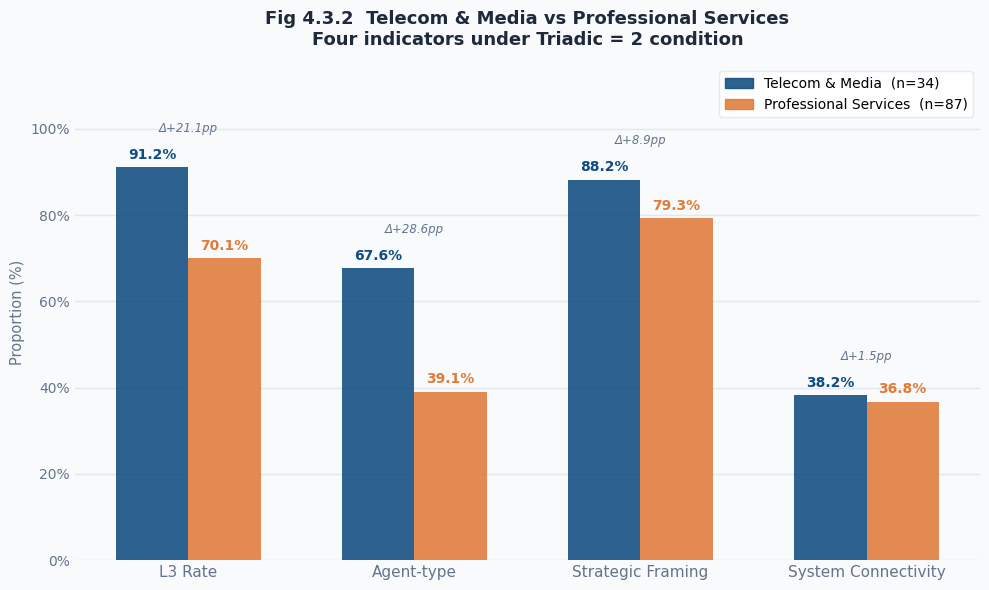

Telecom & Media  n=34: L3=91.2% | Agent=67.6% | Strategic=88.2% | System=38.2%
Professional Svc n=87: L3=70.1% | Agent=39.1% | Strategic=79.3% | System=36.8%


In [2]:
#Figure 9: 4.3.2 Telecom vs Prof Services，triadic=2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── 筛选数据 ──────────────────────────────────────────────────────────────
t2 = df[df['triadic_layers_count'] == 2].copy()

telecom  = t2[t2['industry_reclassified'] == 'Telecom & Media']
profserv = t2[t2['industry_reclassified'] == 'Professional Services']

def calc_metrics(subset):
    n = len(subset)
    return {
        'L3率':              (subset['arch_level'] == 3).sum() / n * 100,
        'Agent型':           (subset['agency_type'] == 'Agent').sum() / n * 100,
        'Strategic framing': (subset['integration_framing'] == 'Strategic').sum() / n * 100,
        'System connectivity':(subset['data_connectivity'] == 'System').sum() / n * 100,
        'n': n
    }

m_tel  = calc_metrics(telecom)
m_pro  = calc_metrics(profserv)

metrics = ['L3率', 'Agent型', 'Strategic framing', 'System connectivity']
labels  = ['L3 Rate', 'Agent-type', 'Strategic Framing', 'System Connectivity']

val_tel = [m_tel[m]  for m in metrics]
val_pro = [m_pro[m]  for m in metrics]

# ── 颜色 ─────────────────────────────────────────────────────────────────
C_tel  = '#0F4C81'   # 深蓝 Telecom
C_pro  = '#E07B39'   # 橙   Prof Services
C_bg   = '#F8FAFC'
C_text = '#1E293B'
C_sub  = '#64748B'
C_grid = '#E2E8F0'

# ── 画图 ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6), facecolor=C_bg)
ax.set_facecolor(C_bg)

x     = np.arange(len(labels))
width = 0.32

bars_tel = ax.bar(x - width/2, val_tel, width, color=C_tel, alpha=0.88, zorder=3)
bars_pro = ax.bar(x + width/2, val_pro, width, color=C_pro, alpha=0.88, zorder=3)

# 数值标签
for bar in bars_tel:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1.2,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=10,
            fontweight='bold', color=C_tel)

for bar in bars_pro:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1.2,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=10,
            fontweight='bold', color=C_pro)

# 差值标注
for i, (v1, v2) in enumerate(zip(val_tel, val_pro)):
    diff = v1 - v2
    sign = '+' if diff > 0 else ''
    ax.text(x[i], max(v1, v2) + 7.5,
            f'Δ{sign}{diff:.1f}pp', ha='center', va='bottom',
            fontsize=8.5, color=C_sub, style='italic')

# 格式
ax.set_ylim(0, 115)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, color=C_text)
ax.set_ylabel('Proportion (%)', fontsize=10.5, color=C_sub)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.tick_params(colors=C_sub, length=0)
ax.grid(axis='y', color=C_grid, linewidth=1, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# 标题
ax.set_title(
    'Fig 4.3.2  Telecom & Media vs Professional Services\n'
    'Four indicators under Triadic = 2 condition',
    fontsize=13, fontweight='bold', color=C_text, pad=14)

# 图例
legend = [
    mpatches.Patch(color=C_tel, alpha=0.88,
                   label=f'Telecom & Media  (n={m_tel["n"]})'),
    mpatches.Patch(color=C_pro, alpha=0.88,
                   label=f'Professional Services  (n={m_pro["n"]})'),
]
ax.legend(handles=legend, loc='upper right', fontsize=10,
          frameon=True, framealpha=0.9, edgecolor=C_grid)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Microsoft900cases/fig_4_3_2_telecom_vs_profserv.png',
            dpi=160, bbox_inches='tight', facecolor=C_bg)
plt.show()
print(f"Telecom & Media  n={m_tel['n']}: L3={m_tel['L3率']:.1f}% | Agent={m_tel['Agent型']:.1f}% | Strategic={m_tel['Strategic framing']:.1f}% | System={m_tel['System connectivity']:.1f}%")
print(f"Professional Svc n={m_pro['n']}: L3={m_pro['L3率']:.1f}% | Agent={m_pro['Agent型']:.1f}% | Strategic={m_pro['Strategic framing']:.1f}% | System={m_pro['System connectivity']:.1f}%")

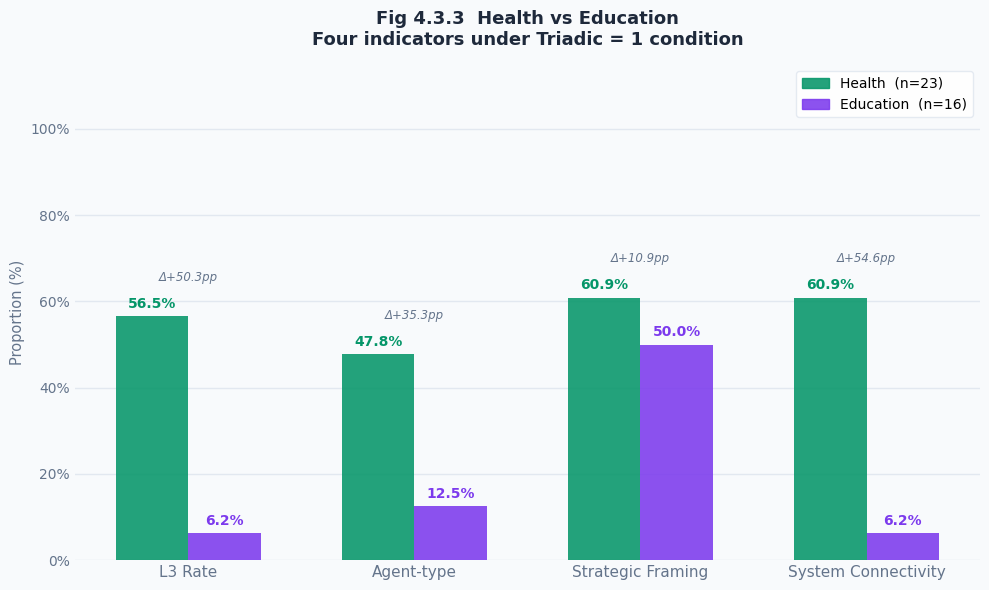

Health    n=23: L3=56.5% | Agent=47.8% | Strategic=60.9% | System=60.9%
Education n=16: L3=6.2% | Agent=12.5% | Strategic=50.0% | System=6.2%


In [3]:
#Figure 10: 4.3.3 Health vs Education，triadic=1
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── 筛选数据 ──────────────────────────────────────────────────────────────
t1 = df[df['triadic_layers_count'] == 1].copy()

health = t1[t1['industry_reclassified'] == 'Health']
edu    = t1[t1['industry_reclassified'] == 'Education']

def calc_metrics(subset):
    n = len(subset)
    return {
        'L3率':               (subset['arch_level'] == 3).sum() / n * 100,
        'Agent型':            (subset['agency_type'] == 'Agent').sum() / n * 100,
        'Strategic framing':  (subset['integration_framing'] == 'Strategic').sum() / n * 100,
        'System connectivity':(subset['data_connectivity'] == 'System').sum() / n * 100,
        'n': n
    }

m_hea = calc_metrics(health)
m_edu = calc_metrics(edu)

metrics = ['L3率', 'Agent型', 'Strategic framing', 'System connectivity']
labels  = ['L3 Rate', 'Agent-type', 'Strategic Framing', 'System Connectivity']

val_hea = [m_hea[m] for m in metrics]
val_edu = [m_edu[m] for m in metrics]

# ── 颜色 ─────────────────────────────────────────────────────────────────
C_hea  = '#059669'   # 绿  Health
C_edu  = '#7C3AED'   # 紫  Education
C_bg   = '#F8FAFC'
C_text = '#1E293B'
C_sub  = '#64748B'
C_grid = '#E2E8F0'

# ── 画图 ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6), facecolor=C_bg)
ax.set_facecolor(C_bg)

x     = np.arange(len(labels))
width = 0.32

bars_hea = ax.bar(x - width/2, val_hea, width, color=C_hea, alpha=0.88, zorder=3)
bars_edu = ax.bar(x + width/2, val_edu, width, color=C_edu, alpha=0.88, zorder=3)

# 数值标签
for bar in bars_hea:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1.2,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=10,
            fontweight='bold', color=C_hea)

for bar in bars_edu:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1.2,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=10,
            fontweight='bold', color=C_edu)

# 差值标注
for i, (v1, v2) in enumerate(zip(val_hea, val_edu)):
    diff = v1 - v2
    sign = '+' if diff > 0 else ''
    ax.text(x[i], max(v1, v2) + 7.5,
            f'Δ{sign}{diff:.1f}pp', ha='center', va='bottom',
            fontsize=8.5, color=C_sub, style='italic')

# 格式
ax.set_ylim(0, 115)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11, color=C_text)
ax.set_ylabel('Proportion (%)', fontsize=10.5, color=C_sub)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.tick_params(colors=C_sub, length=0)
ax.grid(axis='y', color=C_grid, linewidth=1, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# 标题
ax.set_title(
    'Fig 4.3.3  Health vs Education\n'
    'Four indicators under Triadic = 1 condition',
    fontsize=13, fontweight='bold', color=C_text, pad=14)

# 图例
legend = [
    mpatches.Patch(color=C_hea, alpha=0.88,
                   label=f'Health  (n={m_hea["n"]})'),
    mpatches.Patch(color=C_edu, alpha=0.88,
                   label=f'Education  (n={m_edu["n"]})'),
]
ax.legend(handles=legend, loc='upper right', fontsize=10,
          frameon=True, framealpha=0.9, edgecolor=C_grid)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Microsoft900cases/fig_4_3_3_health_vs_education.png',
            dpi=160, bbox_inches='tight', facecolor=C_bg)
plt.show()
print(f"Health    n={m_hea['n']}: L3={m_hea['L3率']:.1f}% | Agent={m_hea['Agent型']:.1f}% | Strategic={m_hea['Strategic framing']:.1f}% | System={m_hea['System connectivity']:.1f}%")
print(f"Education n={m_edu['n']}: L3={m_edu['L3率']:.1f}% | Agent={m_edu['Agent型']:.1f}% | Strategic={m_edu['Strategic framing']:.1f}% | System={m_edu['System connectivity']:.1f}%")

#4.4 Discursive Evidence: Institutional Traces of Platform Discourse and the Corroboration of Architecture-Discourse Synergy

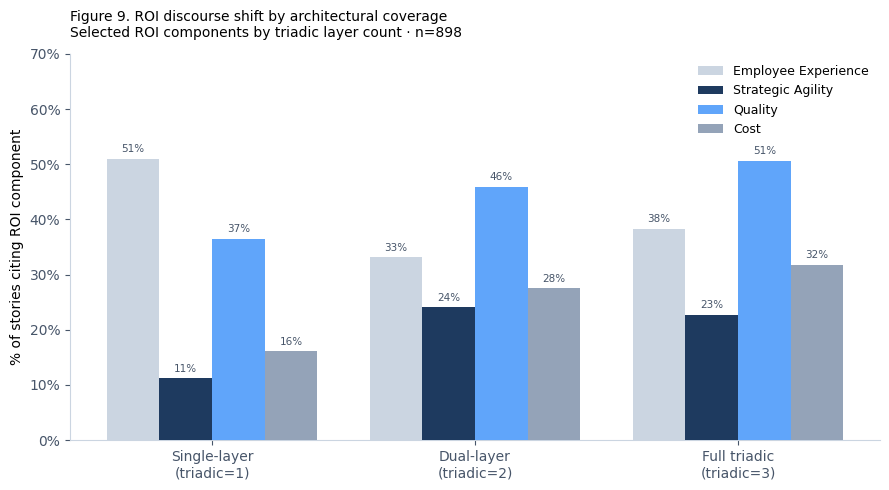

Saved: fig_4_4_1_roi_shift.png


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — FIGURE 11
# 4.4.1 — ROI话语重心转移：grouped bar by triadic level
# Employee Experience vs Strategic Agility vs Quality vs Cost
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

df = pd.read_csv('/content/drive/MyDrive/Microsoft900cases/master_dataset_900.csv')

COLORS = {'EE': '#CBD5E1', 'SA': '#1E3A5F', 'Quality': '#60A5FA', 'Cost': '#94A3B8'}
plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': False})

triadic_levels = [1, 2, 3]
labels_x = ['Single-layer\n(triadic=1)', 'Dual-layer\n(triadic=2)', 'Full triadic\n(triadic=3)']
roi_items = {
    'Employee Experience': COLORS['EE'],
    'Strategic Agility':   COLORS['SA'],
    'Quality':             COLORS['Quality'],
    'Cost':                COLORS['Cost'],
}

data = {}
for comp, color in roi_items.items():
    data[comp] = [
        df[df['triadic_layers_count']==t]['roi_metric']
          .str.contains(comp, na=False).mean()*100
        for t in triadic_levels
    ]

x = np.arange(len(triadic_levels))
width = 0.2
n_items = len(roi_items)
offsets = np.linspace(-(n_items-1)/2, (n_items-1)/2, n_items) * width

fig, ax = plt.subplots(figsize=(9, 5))

for i, (comp, color) in enumerate(roi_items.items()):
    vals = data[comp]
    bars = ax.bar(x + offsets[i], vals, width, color=color, label=comp, zorder=3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=7.5, color='#475569')

ax.set_xticks(x)
ax.set_xticklabels(labels_x, fontsize=10)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_ylabel('% of stories citing ROI component', fontsize=10)
ax.set_ylim(0, 70)
ax.set_title('Figure 9. ROI discourse shift by architectural coverage\n'
             'Selected ROI components by triadic layer count · n=898',
             fontsize=10, loc='left', pad=12)
ax.legend(frameon=False, fontsize=9, loc='upper right')
ax.spines['left'].set_color('#CBD5E1')
ax.spines['bottom'].set_color('#CBD5E1')
ax.tick_params(colors='#475569')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Microsoft900cases/fig_4_4_1_roi_shift.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: fig_4_4_1_roi_shift.png")


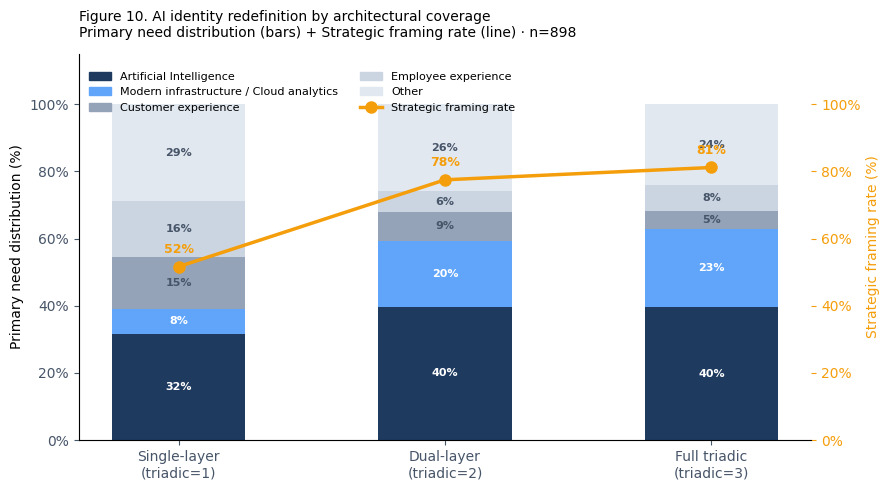

Saved: fig_4_4_2_ai_identity.png


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — FIGURE 12
# 4.4.2 — AI身份重新定义：primary_need构成 + Strategic framing比率
# stacked area (primary need top categories) + line overlay (strategic framing)
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

df = pd.read_csv('/content/drive/MyDrive/Microsoft900cases/master_dataset_900.csv')

COLORS = {'AI': '#1E3A5F', 'infra': '#60A5FA', 'cx': '#94A3B8',
          'ee': '#CBD5E1', 'other': '#E2E8F0', 'line': '#F59E0B'}
plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': False})

triadic_levels = [1, 2, 3]
labels_x = ['Single-layer\n(triadic=1)', 'Dual-layer\n(triadic=2)', 'Full triadic\n(triadic=3)']

need_categories = {
    'Artificial Intelligence': COLORS['AI'],
    'Modern infrastructure /\nCloud analytics':      COLORS['infra'],
    'Customer experience':     COLORS['cx'],
    'Employee experience':     COLORS['ee'],
}

def get_need_rate(t, need):
    sub = df[df['triadic_layers_count']==t]
    if 'Cloud' in need:
        return (sub['primary_need'].isin(['Modern infrastructure','Cloud-scale analytics'])).mean()*100
    return (sub['primary_need']==need).mean()*100

data_needs = {}
for need in need_categories:
    data_needs[need] = [get_need_rate(t, need) for t in triadic_levels]

# Other
data_needs['Other'] = [
    100 - sum(data_needs[n][i] for n in list(need_categories.keys()))
    for i in range(3)
]

strategic_rates = [
    (df[df['triadic_layers_count']==t]['integration_framing']=='Strategic').mean()*100
    for t in triadic_levels
]

x = np.arange(len(triadic_levels))
width = 0.5

fig, ax1 = plt.subplots(figsize=(9, 5))

bottoms = np.zeros(3)
all_needs = list(need_categories.keys()) + ['Other']
all_colors = list(need_categories.values()) + [COLORS['other']]

for need, color in zip(all_needs, all_colors):
    vals = np.array(data_needs[need])
    ax1.bar(x, vals, width, bottom=bottoms, color=color,
            label=need.replace('\n', ' '), zorder=3)
    # label inside bar if big enough
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 5:
            ax1.text(x[i], b + v/2, f'{v:.0f}%',
                     ha='center', va='center', fontsize=8,
                     color='white' if color in [COLORS['AI'], COLORS['infra']] else '#475569',
                     fontweight='bold')
    bottoms += vals

# Strategic framing line on second axis
ax2 = ax1.twinx()
ax2.plot(x, strategic_rates, color=COLORS['line'], linewidth=2.5,
         marker='o', markersize=8, zorder=5, label='Strategic framing rate')
for xi, val in zip(x, strategic_rates):
    ax2.annotate(f'{val:.0f}%', xy=(xi, val), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontsize=9,
                 color=COLORS['line'], fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(labels_x, fontsize=10)
ax1.set_ylabel('Primary need distribution (%)', fontsize=10)
ax1.set_ylim(0, 115)
ax1.yaxis.set_major_formatter(PercentFormatter())

ax2.set_ylabel('Strategic framing rate (%)', fontsize=10, color=COLORS['line'])
ax2.tick_params(axis='y', colors=COLORS['line'])
ax2.set_ylim(0, 115)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.spines['right'].set_color(COLORS['line'])

ax1.set_title('Figure 10. AI identity redefinition by architectural coverage\n'
              'Primary need distribution (bars) + Strategic framing rate (line) · n=898',
              fontsize=10, loc='left', pad=12)

lines2, labels2 = ax2.get_legend_handles_labels()
bars_legend = [plt.Rectangle((0,0),1,1, color=c) for c in all_colors]
ax1.legend(bars_legend + lines2,
           [n.replace('\n',' ') for n in all_needs] + labels2,
           frameon=False, fontsize=8, loc='upper left',
           bbox_to_anchor=(0, 0.98), ncol=2)

ax1.spines['left'].set_color('#CBD5E1')
ax1.spines['bottom'].set_color('#CBD5E1')
ax1.tick_params(colors='#475569')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Microsoft900cases/fig_4_4_2_ai_identity.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: fig_4_4_2_ai_identity.png")

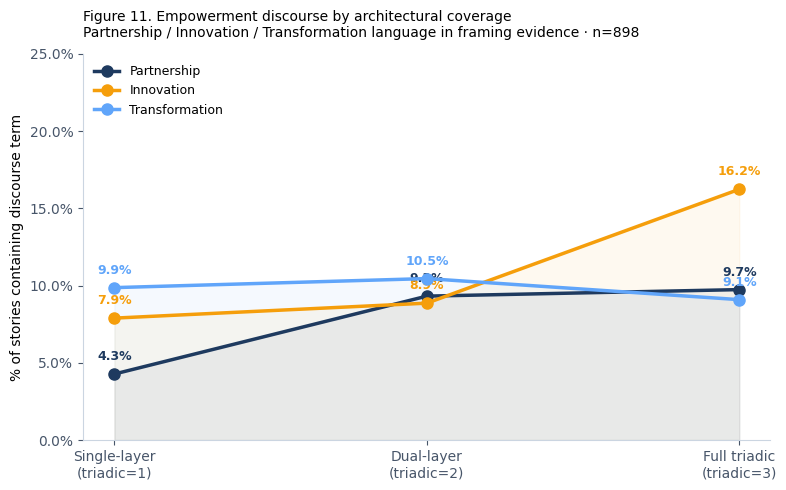

Saved: fig_4_4_3_discourse_shift.png


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — FIGURE 13
# 4.4.3 — Partnership/Innovation语言随triadic增加
# Line chart: partnership + innovation framing rates by triadic level
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

df = pd.read_csv('/content/drive/MyDrive/Microsoft900cases/master_dataset_900.csv')

COLORS = {'partner': '#1E3A5F', 'innovat': '#F59E0B', 'transform': '#60A5FA'}
plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': False})

triadic_levels = [1, 2, 3]
labels_x = ['Single-layer\n(triadic=1)', 'Dual-layer\n(triadic=2)', 'Full triadic\n(triadic=3)']

discourse_items = {
    'Partnership':    ('partner',    COLORS['partner']),
    'Innovation':     ('innovat',    COLORS['innovat']),
    'Transformation': ('transform',  COLORS['transform']),
}

x = np.arange(len(triadic_levels))

fig, ax = plt.subplots(figsize=(8, 5))

for label, (kw, color) in discourse_items.items():
    rates = [
        df[df['triadic_layers_count']==t]['framing_evidence_sentence']
          .str.lower().str.contains(kw, na=False).mean()*100
        for t in triadic_levels
    ]
    ax.plot(x, rates, color=color, linewidth=2.5, marker='o',
            markersize=8, label=label, zorder=3)
    ax.fill_between(x, rates, alpha=0.06, color=color)
    for xi, val in zip(x, rates):
        ax.annotate(f'{val:.1f}%', xy=(xi, val), xytext=(0, 10),
                    textcoords='offset points', ha='center',
                    fontsize=9, color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels_x, fontsize=10)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_ylabel('% of stories containing discourse term', fontsize=10)
ax.set_ylim(0, 25)
ax.set_title('Figure 11. Empowerment discourse by architectural coverage\n'
             'Partnership / Innovation / Transformation language in framing evidence · n=898',
             fontsize=10, loc='left', pad=12)
ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.spines['left'].set_color('#CBD5E1')
ax.spines['bottom'].set_color('#CBD5E1')
ax.tick_params(colors='#475569')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Microsoft900cases/fig_4_4_3_discourse_shift.png', dpi=180, bbox_inches='tight')
plt.show()
print("Saved: fig_4_4_3_discourse_shift.png")
